# Ejercicio 02 · Ensambles, reducción y Green AI

Marlenis Judith Concepción Cuevas · INF-8239-C2

Ionosphere es una propuesta pendiente de aprobación docente. Se siguen los mandatos y rúbricas compartidos; faltan los capítulos completos LAB01–LAB03.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
from IPython.display import display, Image, Markdown

## Protocolo
Separación estratificada 60/20/20, semilla 42. Duplicados exactos retirados antes de la partición; ninguna transformación se ajusta con validación o prueba. Métrica principal: F1 macro. El test no decide parámetros ni configuraciones.

In [2]:
from laboratorio_e02 import ejecutar
resultados = ejecutar()
display(resultados)

   modelo  ajuste_s  inferencia_ms_fila  tamano_kib  accuracy  f1_macro  precision_macro  recall_b  recall_g  roc_auc  pareto
   RF_150   0.11166             0.07668   464.00195   0.94286   0.93525          0.95918      0.84   1.00000  0.98222   False
    RF_50   0.03676             0.03364   123.22070   0.94286   0.93525          0.95918      0.84   1.00000  0.97689   False
   GB_100   0.10406             0.01229    84.92285   0.94286   0.93525          0.95918      0.84   1.00000  0.97156   False
    GB_50   0.05399             0.01161    49.61035   0.94286   0.93525          0.95918      0.84   1.00000  0.97333    True
SVM_PCA95   0.00351             0.01485    22.26270   0.94286   0.93525          0.95918      0.84   1.00000  0.99467   False
      SVM   0.00303             0.01360    20.30957   0.95714   0.95290          0.95743      0.92   0.97778  0.99556    True
Modelo elegido: GB_50
modelo particion  accuracy  f1_macro  precision_macro  recall_b  recall_g  roc_auc
 GB_50    pru

,modelo,ajuste_s,inferencia_ms_fila,tamano_kib,accuracy,f1_macro,precision_macro,recall_b,recall_g,roc_auc,pareto
0,RF_150,0.111663,0.076683,464.001953,0.942857,0.935245,0.959184,0.84,1.000000,0.982222,False
1,RF_50,0.036759,0.033643,123.220703,0.942857,0.935245,0.959184,0.84,1.000000,0.976889,False
2,GB_100,0.104056,0.012289,84.922852,0.942857,0.935245,0.959184,0.84,1.000000,0.971556,False
3,GB_50,0.053991,0.011610,49.610352,0.942857,0.935245,0.959184,0.84,1.000000,0.973333,True
4,SVM_PCA95,0.003507,0.014847,22.262695,0.942857,0.935245,0.959184,0.84,1.000000,0.994667,False
5,SVM,0.003029,0.013598,20.309570,0.957143,0.952904,0.957428,0.92,0.977778,0.995556,True


## Medición y decisión
Seis configuraciones, tres repeticiones con la misma semilla y orden alternado. Un hilo, calentamiento excluido y 30 predicciones por lote en cada repetición. Se informa la mediana temporal; no equivale a incertidumbre estadística ni a energía medida. Pareto usa F1, tiempo de ajuste, inferencia y tamaño. Se elige menor latencia entre no dominados a un máximo de 0.02 del mejor F1 de validación.

,modelo,repeticion,ajuste_s,inferencia_ms_fila,tamano_kib,accuracy,f1_macro,precision_macro,recall_b,recall_g,roc_auc
0,RF_150,1,0.111281,0.076683,464.001953,0.942857,0.935245,0.959184,0.84,1.000000,0.982222
1,RF_50,1,0.036156,0.033643,123.220703,0.942857,0.935245,0.959184,0.84,1.000000,0.976889
2,GB_100,1,0.105967,0.012723,84.922852,0.942857,0.935245,0.959184,0.84,1.000000,0.971556
3,GB_50,1,0.051655,0.011789,49.610352,0.942857,0.935245,0.959184,0.84,1.000000,0.973333
4,SVM_PCA95,1,0.003507,0.014847,22.262695,0.942857,0.935245,0.959184,0.84,1.000000,0.994667
5,SVM,1,0.003151,0.015129,20.309570,0.957143,0.952904,0.957428,0.92,0.977778,0.995556
6,GB_100,2,0.104056,0.012289,84.922852,0.942857,0.935245,0.959184,0.84,1.000000,0.971556
7,SVM_PCA95,2,0.003493,0.014662,22.262695,0.942857,0.935245,0.959184,0.84,1.000000,0.994667
8,GB_50,2,0.053991,0.011554,49.610352,0.942857,0.935245,0.959184,0.84,1.000000,0.973333
9,RF_50,2,0.036916,0.033492,123.220703,0.942857,0.935245,0.959184,0.84,1.000000,0.976889


,modelo,particion,accuracy,f1_macro,precision_macro,recall_b,recall_g,roc_auc
0,GB_50,prueba,0.928571,0.921507,0.925725,0.88,0.955556,0.964


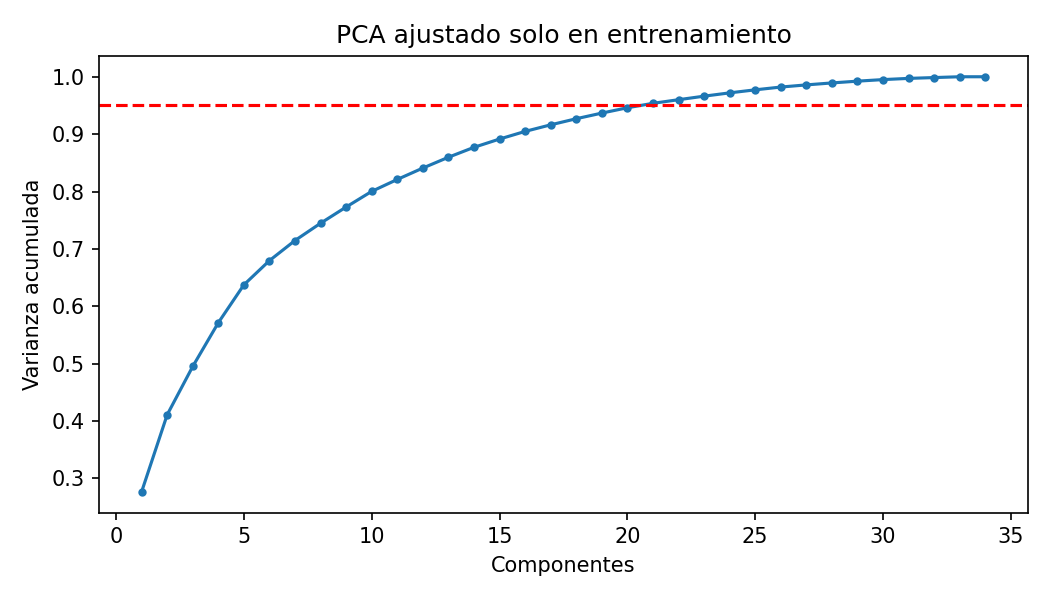

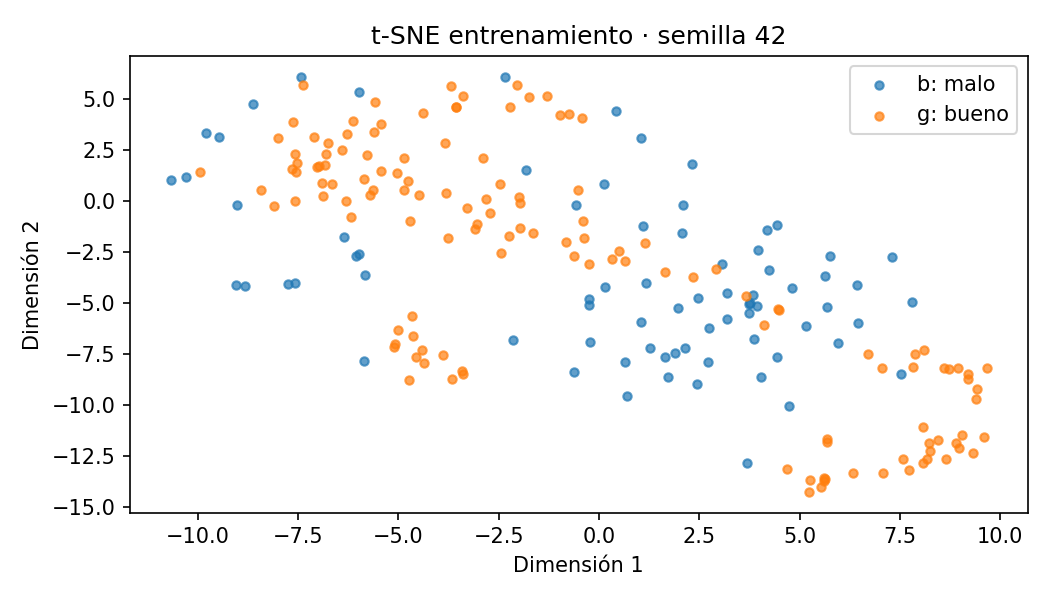

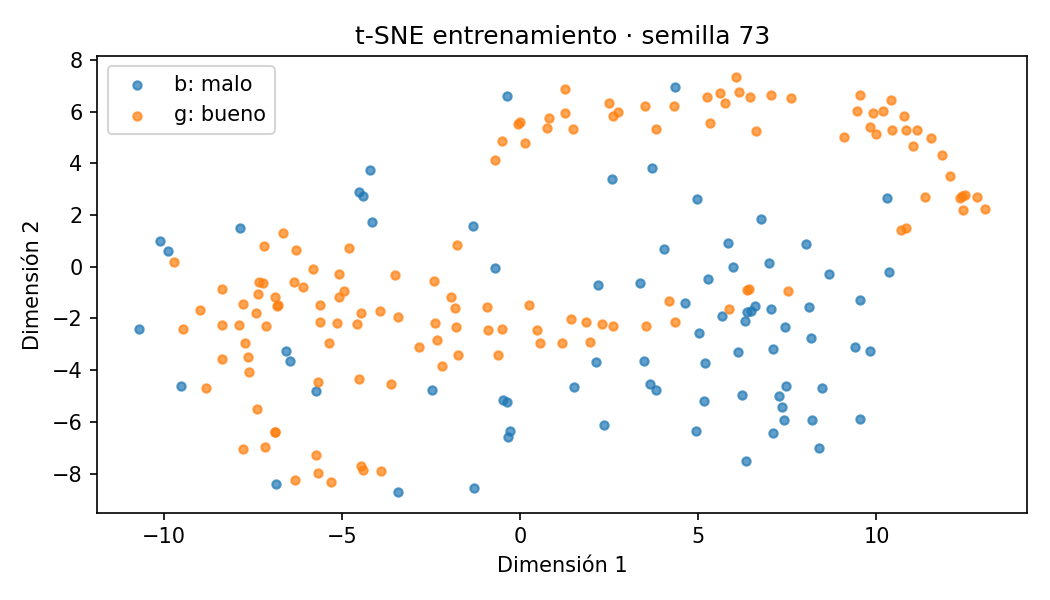

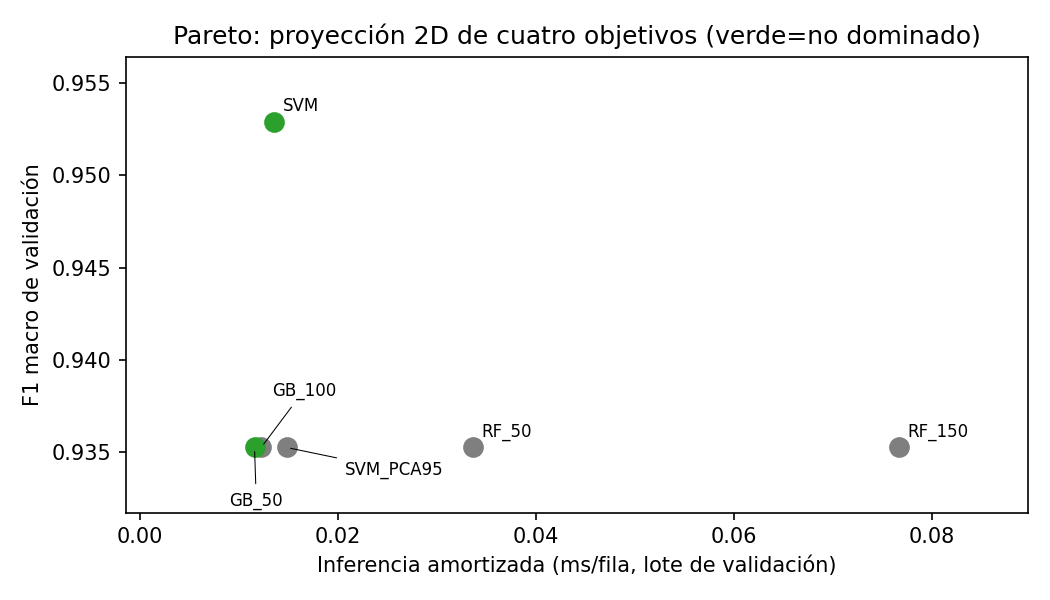

,semilla,perplexity,trustworthiness_k5,kl_divergence
0,42,30,0.890641,0.396205
1,73,30,0.891612,0.350921


In [3]:
display(pd.read_csv(ROOT / 'reports/repeticiones.csv'))
display(pd.read_csv(ROOT / 'reports/prueba_final.csv'))
for nombre in ['pca.png','tsne_42.png','tsne_73.png','pareto.png']:
    display(Image(filename=str(ROOT / 'reports' / nombre)))
display(pd.read_csv(ROOT / 'reports/tsne_calidad.csv'))

In [4]:
from informe import generar
generar()
display(Markdown((ROOT / "reports/conclusion.md").read_text()))

PDF 02 y conclusión generados


# Conclusión · borrador para revisión personal

Se compararon seis configuraciones sobre las mismas 350 observaciones, target y partición del Ejercicio 01: SVM, SVM con PCA al 95%, dos Random Forest y dos Gradient Boosting. Los parámetros del SVM proceden de la búsqueda previa sobre entrenamiento; las alternativas de ensambles se fijaron antes de evaluar validación. El conjunto de prueba se utilizó únicamente después de registrar la decisión de este ejercicio. La aprobación docente del dataset continúa pendiente.

La comparación priorizó F1 macro de validación. El mayor valor fue 0.953. La regla previamente definida admitió una pérdida máxima de 0.02 frente a ese valor y seleccionó la menor latencia entre las configuraciones no dominadas. La frontera consideró simultáneamente F1, tiempo de entrenamiento, inferencia amortizada y tamaño serializado. Resultó seleccionado GB_50, con F1 de validación 0.935, ajuste de 0.0540 segundos, inferencia de 0.0116 milisegundos por fila y tamaño de 49.6 KiB. La diferencia frente al máximo fue 0.018. Su F1 macro final en prueba fue 0.922.

Cada configuración se entrenó tres veces con la misma semilla, usando un hilo y alternando el orden. Se excluyó el calentamiento y se midieron treinta predicciones del lote de validación por repetición. Los valores publicados son medianas. La latencia por fila se obtiene dividiendo el tiempo del lote entre sus observaciones; no representa una solicitud individual en producción. Estas repeticiones caracterizan el tiempo local, no la incertidumbre de generalización. El tamaño corresponde al archivo del pipeline completo sin compresión y no mide memoria RAM máxima.

PCA necesitó 21 componentes para retener al menos el 95% de la varianza de entrenamiento. El SVM sin reducción obtuvo F1 de validación 0.953, frente a 0.935 con PCA; conservar varianza no garantiza conservar toda la información discriminativa. Las dos proyecciones t-SNE usan semillas 42 y 73, con perplexity 30. Su preservación de vecindades, medida mediante trustworthiness con cinco vecinos, fue 0.891 y 0.892. En la semilla 42 se observa una zona de retornos buenos en la parte superior izquierda y otra hacia la inferior derecha, con retornos malos más presentes en el centro derecho. En la semilla 73 cambia la disposición: aparece una banda de buenos en la parte superior y se mantiene mezcla de clases en zonas centrales. Ningún mapa separa por completo ambas clases. Las figuras deben interpretarse como exploración local: cambios de orientación, distancias entre grupos o separación aparente no demuestran capacidad predictiva.

La decisión expresa un compromiso medido en este equipo y podría cambiar con hardware, carga o tamaño de lote. No se midieron energía ni emisiones, por lo que no se atribuyen ahorros de kWh o CO2. Se conservaron modelos, resultados individuales y evidencia de la partición para revisión. Antes de entregar, corresponde confirmar la selección con el profesor y revisar personalmente la interpretación y los límites del experimento.


## Fuentes y límites
[UCI Ionosphere](https://archive.ics.uci.edu/dataset/52/ionosphere), CC BY 4.0.
[Prevención de fuga, scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html).
[Documentación t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).

La muestra histórica de un radar no permite afirmar generalización a otros radares. Las conclusiones son un borrador basado en ejecuciones reales que la estudiante debe revisar y defender.